# MVP — Diagnóstico de calidad de red y soporte a decisión de inversión/mantenimiento

**TFM Grupo 1 — OBS Business School**  
**Ejecutar:** Kernel → Restart → Run All (debe completar sin error)

---

| Sección | Owner | Input | Output |
|---------|-------|-------|--------|
| §0 Setup | Dev-1 | — | Constantes, paths |
| §1 Carga | Dev-1 | `db_files/` | `df_claims`, `df_location`, `df_kpis` |
| §2 Dataset semanal | Dev-1 | DataFrames crudos | `df_weekly` + Parquet |
| §3 EDA | Dev-2 | `df_weekly` | Figuras, hallazgos |
| §4 Features + split | Dev-1 | `df_weekly` | `X_train/test`, `y_train/test` |
| §5 Modelos | Dev-2 | X/y splits | `model_rules/lr/xgb` |
| §6 Evaluación | Dev-2 | predicciones | `df_metrics`, figura AUC-PR |
| §7 SHAP | Dev-3 | `model_xgb`, `X_test` | `shap_values`, figuras |
| §8 Clustering | Dev-3 | `df_weekly` | `df_sites_clustered` |
| §9 Ranking | Dev-3 | score + SHAP + clusters | `df_ranking` + Parquet |

In [63]:
# Colab no trae optuna/shap/xgboost preinstalados -- instalar solo si hace falta.
try:
    import google.colab  # noqa: F401
    %pip install -q optuna shap xgboost
except ImportError:
    pass

## §0 — Setup & configuración global

**Owner:** Dev-1  
**Input:** —  
**Output:** constantes globales, paths  
**Dependencias:** ninguna

In [64]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Detecta Colab vs. entorno local — permite un solo notebook para ambos casos
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Carpeta dedicada del notebook en Drive (separada del remote DVC)
    drive.mount('/content/drive')
    ROOT_DIR = Path('/content/drive/MyDrive/TFM-local')
else:
    # Permite importar desde src/ independientemente del CWD
    ROOT_DIR = Path().resolve().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# — Reproducibilidad —
RANDOM_STATE      = 42

# — Parámetros de modelado —
ROLLING_WINDOW    = 7            # días
WEEK_ANCHOR       = "W-SUN"      # fin de semana = domingo
TEST_CUTOFF_DATE  = "2026-02-01" # split temporal train/test

# — Umbrales de negocio (derivados del EDA: entregables/eda-hallazgos.md) —
AVA_THRESHOLD     = 0.98         # tasa queja 3-4x por debajo
DC_THRESHOLD      = 0.02         # tasa queja 2x por encima
THP_THRESHOLD_MBP = 15.0         # Mbps, tasa queja 2-3x por debajo

# — Columnas clave —
SITE_ID_COL  = "site_id"
WEEK_COL     = "semana"
TARGET_COL   = "es_reclamo_semanal"

# — Paths —
OUTPUT_DIR  = ROOT_DIR / "output"
FIGURES_DIR = OUTPUT_DIR / "semanal" / "figures"
DATA_WEEKLY = OUTPUT_DIR / "modeling_dataset_weekly.parquet"
RANKING_PATH = OUTPUT_DIR / "semanal" / "ranking_sitios.parquet"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT_DIR   : {ROOT_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"DATA_WEEKLY: {DATA_WEEKLY}")
print(f"RANDOM_STATE = {RANDOM_STATE} | TEST_CUTOFF = {TEST_CUTOFF_DATE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT_DIR   : /content/drive/MyDrive/TFM-local
OUTPUT_DIR : /content/drive/MyDrive/TFM-local/output
DATA_WEEKLY: /content/drive/MyDrive/TFM-local/output/modeling_dataset_weekly.parquet
RANDOM_STATE = 42 | TEST_CUTOFF = 2026-02-01


## §1 — Carga y validación de datos

**Owner:** Dev-1  
**Input:** archivos en `db_files/`  
**Output:** `df_claims`, `df_location`, `df_kpis`  
**Dependencias:** §0

In [65]:
# Si el Parquet semanal ya existe (workflow Colab compartido), no hace falta
# el repo completo ni db_files/ crudo — Dev-2/Dev-3 solo consumen df_weekly (§2).
if DATA_WEEKLY.exists():
    df_claims = df_location = df_kpis = None
    print("Parquet semanal ya disponible — se omite carga de datos crudos (§1).")
else:
    from src.build_modeling_dataset import load_from_files, normalize, validate_integrity

    df_claims, df_location, df_kpis = load_from_files(ROOT_DIR / "db_files")
    df_claims, df_location, df_kpis = normalize(df_claims, df_location, df_kpis)
    validate_integrity(df_claims, df_location, df_kpis)

    print(f"claims   : {df_claims.shape}")
    print(f"location : {df_location.shape}")
    print(f"kpis     : {df_kpis.shape}")

Parquet semanal ya disponible — se omite carga de datos crudos (§1).


In [66]:
# Verificando que los datos se carguen correctamente desde Google Drive
print(f"Expected DATA_WEEKLY path: {DATA_WEEKLY}")
print(f"Does DATA_WEEKLY exist? {DATA_WEEKLY.exists()}")

if not DATA_WEEKLY.exists():
    print(f"Contents of OUTPUT_DIR ({OUTPUT_DIR}):")
    for item in OUTPUT_DIR.iterdir():
        print(f"- {item.name}")
    print("Please ensure 'modeling_dataset_weekly.parquet' is directly within the 'output' folder in your TFM Drive directory, and that the filename is exactly correct.")


Expected DATA_WEEKLY path: /content/drive/MyDrive/TFM-local/output/modeling_dataset_weekly.parquet
Does DATA_WEEKLY exist? True


## §2 — Dataset sitio × semana

**Owner:** Dev-1  
**Input:** `df_claims`, `df_location`, `df_kpis`  
**Output:** `df_weekly` → `output/modeling_dataset_weekly.parquet`  
**Dependencias:** §1

Punto de handoff crítico (H1): Dev-2 y Dev-3 leen desde el Parquet.

In [67]:
# df_weekly se construye con build_weekly() en src/build_modeling_dataset.py
# (agrega claims a sitio×semana, KPIs rolling leakage-safe, normaliza por USERS_4G).
# El notebook no reimplementa esa lógica — solo carga el Parquet ya generado.
if DATA_WEEKLY.exists():
    df_weekly = pd.read_parquet(DATA_WEEKLY)
    print(f"df_weekly cargado desde Parquet: {df_weekly.shape}")
    print(f"Positivos: {df_weekly[TARGET_COL].sum()} / {len(df_weekly)} = {df_weekly[TARGET_COL].mean():.2%}")
else:
    raise FileNotFoundError(
        f"Parquet no encontrado: {DATA_WEEKLY}. "
        "Ejecutar `python src/build_modeling_dataset.py --grain weekly --source files` primero."
    )

df_weekly cargado desde Parquet: (68971, 14)
Positivos: 1730 / 68971 = 2.51%


## §3 — EDA diagnóstico

**Owner:** Dev-2  
**Input:** `df_weekly` (vía Parquet si §2 no está corrido)  
**Output:** figuras en `output/figures/`, hallazgos documentados  
**Dependencias:** §2 (Parquet H1)

Distribución del target:
es_reclamo_semanal
0    0.974917
1    0.025083
Name: proporción, dtype: float64


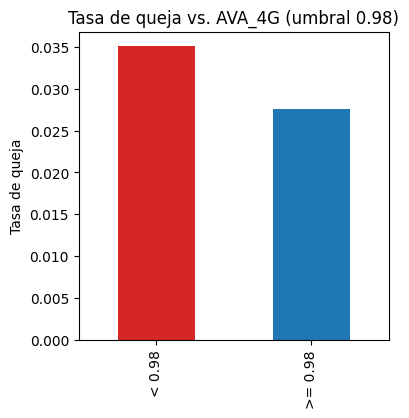

< 0.98     0.035061
>= 0.98    0.027608
Name: es_reclamo_semanal, dtype: float64


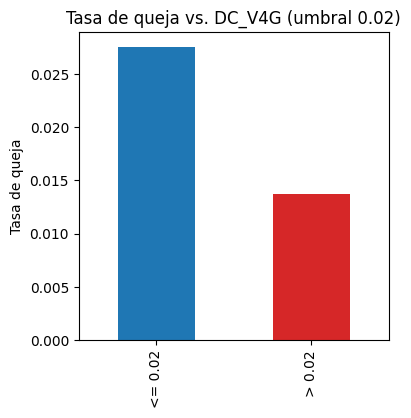

<= 0.02    0.027557
> 0.02     0.013724
Name: es_reclamo_semanal, dtype: float64


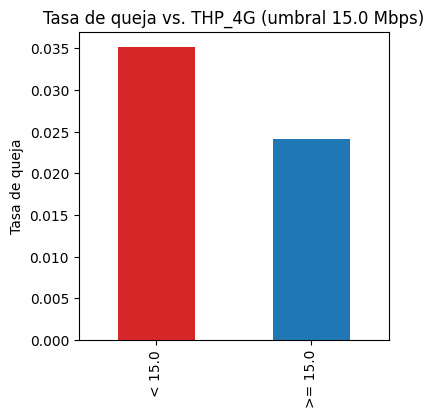

< 15.0     0.035226
>= 15.0    0.024172
Name: es_reclamo_semanal, dtype: float64


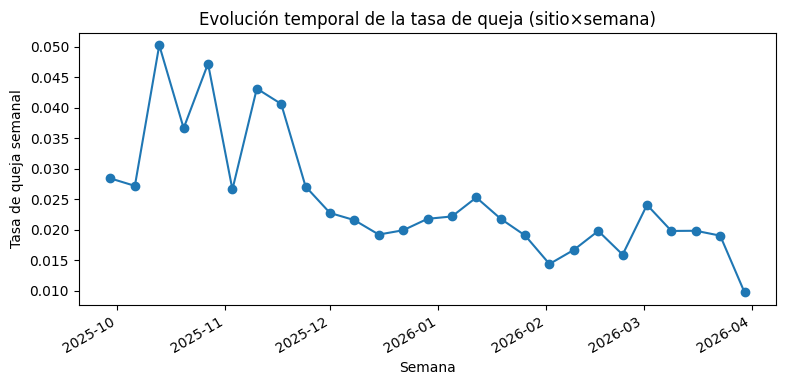

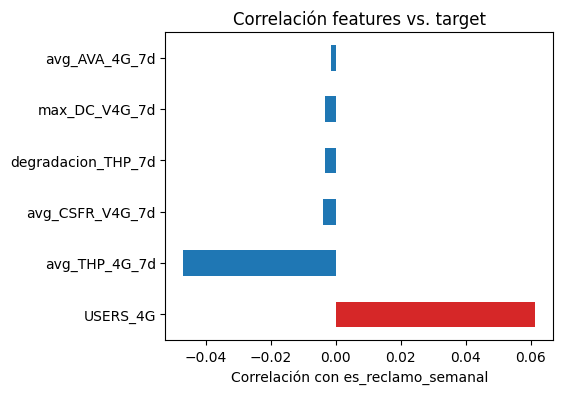

USERS_4G              0.061472
avg_THP_4G_7d        -0.046937
avg_CSFR_V4G_7d      -0.004019
degradacion_THP_7d   -0.003363
max_DC_V4G_7d        -0.003229
avg_AVA_4G_7d        -0.001548
Name: es_reclamo_semanal, dtype: float64


In [68]:
# Asegurar que df_weekly está disponible (puede cargar sin correr §2)
if "df_weekly" not in dir():
    df_weekly = pd.read_parquet(DATA_WEEKLY)

# 1. Distribución del target
print("Distribución del target:")
print(df_weekly[TARGET_COL].value_counts(normalize=True).rename("proporción"))


def _tasa_por_bucket(df: pd.DataFrame, col: str, umbral: float, mayor_es_malo: bool) -> pd.Series:
    """Tasa de queja por encima/debajo del umbral de negocio de la columna."""
    d = df.dropna(subset=[col])
    if mayor_es_malo:
        bucket = np.where(d[col] > umbral, f"> {umbral}", f"<= {umbral}")
    else:
        bucket = np.where(d[col] < umbral, f"< {umbral}", f">= {umbral}")
    return d.groupby(bucket)[TARGET_COL].mean()


# 2. Tasa queja vs. bucket AVA
tasa_ava = _tasa_por_bucket(df_weekly, "avg_AVA_4G_7d", AVA_THRESHOLD, mayor_es_malo=False)
fig_ava_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_ava.plot(kind="bar", ax=ax, color=["#d62728", "#1f77b4"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. AVA_4G (umbral {AVA_THRESHOLD})")
fig_ava_bucket.savefig(FIGURES_DIR / "eda_ava_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_ava)

# 3. Tasa queja vs. bucket DC
tasa_dc = _tasa_por_bucket(df_weekly, "max_DC_V4G_7d", DC_THRESHOLD, mayor_es_malo=True)
fig_dc_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_dc.plot(kind="bar", ax=ax, color=["#1f77b4", "#d62728"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. DC_V4G (umbral {DC_THRESHOLD})")
fig_dc_bucket.savefig(FIGURES_DIR / "eda_dc_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_dc)

# 4. Tasa queja vs. bucket THP
tasa_thp = _tasa_por_bucket(df_weekly, "avg_THP_4G_7d", THP_THRESHOLD_MBP, mayor_es_malo=False)
fig_thp_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_thp.plot(kind="bar", ax=ax, color=["#d62728", "#1f77b4"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. THP_4G (umbral {THP_THRESHOLD_MBP} Mbps)")
fig_thp_bucket.savefig(FIGURES_DIR / "eda_thp_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_thp)

# 5. Evolución temporal de quejas
temporal = df_weekly.groupby(WEEK_COL)[TARGET_COL].agg(n_reclamos="sum", tasa="mean").reset_index()
temporal[WEEK_COL] = temporal[WEEK_COL].dt.start_time
fig_temporal, ax = plt.subplots(figsize=(9, 4))
ax.plot(temporal[WEEK_COL], temporal["tasa"], marker="o")
ax.set_ylabel("Tasa de queja semanal")
ax.set_xlabel("Semana")
ax.set_title("Evolución temporal de la tasa de queja (sitio×semana)")
fig_temporal.autofmt_xdate()
fig_temporal.savefig(FIGURES_DIR / "eda_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Correlación features vs. TARGET_COL
# Columnas de KPI disponibles en df_weekly ya en §3 (FEATURE_COLS se define recién en §4)
_KPI_COLS = ["avg_AVA_4G_7d", "max_DC_V4G_7d", "avg_THP_4G_7d", "degradacion_THP_7d", "avg_CSFR_V4G_7d", "USERS_4G"]
corr = df_weekly[_KPI_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
fig_correlation, ax = plt.subplots(figsize=(5, 4))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#d62728", "#1f77b4"))
ax.set_xlabel(f"Correlación con {TARGET_COL}")
ax.set_title("Correlación features vs. target")
fig_correlation.savefig(FIGURES_DIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(corr)

> **Hallazgo [completar]:** ...  
> **Implicación:** ...

## §4 — Feature engineering y split temporal

**Owner:** Dev-1  
**Input:** `df_weekly`  
**Output:** `X_train`, `X_test`, `y_train`, `y_test`, `FEATURE_COLS`  
**Dependencias:** §2

Punto de handoff H2: Dev-2 y Dev-3 consumen estas variables directamente.

In [69]:
FEATURE_COLS = [
    "avg_AVA_4G_7d",
    "max_DC_V4G_7d",
    "avg_THP_4G_7d",
    "degradacion_THP_7d",
    "avg_CSFR_V4G_7d",
    "USERS_4G",
    # "reclamos_por_usuario" -- NO USAR: es n_reclamos_semana / USERS_4G, calculado con
    # el conteo de reclamos de la MISMA semana que define TARGET_COL -> data leakage directo.
    # Categoricals one-hot-encoded
    # "tipo_negocio_B2C", "tipo_negocio_B2B", "tipo_negocio_PREPAGO",
]

# Filas sin ventana rolling previa (primera semana con datos por sitio) quedan con nulos
# en FEATURE_COLS -- no es missing real, es artefacto de .shift(1).rolling(). Se descartan.
# degradacion_THP_7d puede dar inf si avg_THP_4G_7d es 0 (denominador) -- dropna() no
# atrapa inf, hay que convertirlo a NaN primero para que se descarte igual que los demás.
df_model = df_weekly.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURE_COLS).copy()
print(f"Filas descartadas (sin ventana rolling): {len(df_weekly) - len(df_model)} "
      f"({1 - len(df_model) / len(df_weekly):.1%})")

# Split temporal -- nunca aleatorio en series de tiempo
mask_train = df_model[WEEK_COL] < TEST_CUTOFF_DATE
df_train   = df_model[mask_train].copy()
df_test    = df_model[~mask_train].copy()

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]
X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET_COL]

print(f"Train: {X_train.shape} | positivos={y_train.sum()} ({y_train.mean():.2%})")
print(f"Test : {X_test.shape}  | positivos={y_test.sum()} ({y_test.mean():.2%})")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Filas descartadas (sin ventana rolling): 8353 (12.1%)
Train: (37425, 6) | positivos=1238 (3.31%)
Test : (23193, 6)  | positivos=450 (1.94%)
Features (6): ['avg_AVA_4G_7d', 'max_DC_V4G_7d', 'avg_THP_4G_7d', 'degradacion_THP_7d', 'avg_CSFR_V4G_7d', 'USERS_4G']


## §5 — Modelos (baseline / LR / XGBoost)

**Owner:** Dev-2  
**Input:** `X_train`, `X_test`, `y_train`, `y_test`, `FEATURE_COLS`, `RANDOM_STATE`  
**Output:** `model_rules`, `model_lr`, `model_xgb`, `y_pred_*`, `y_prob_*`  
**Dependencias:** §4 (handoff H2)

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
import optuna
from sklearn.impute import SimpleImputer # Import SimpleImputer

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Baseline de reglas ---
class RulesBaseline:
    """Flag si AVA < umbral OR DC > umbral OR THP < umbral (umbrales de negocio, EDA)."""

    def _rule_count(self, X: pd.DataFrame) -> pd.Series:
        return (
            (X["avg_AVA_4G_7d"] < AVA_THRESHOLD).astype(int)
            + (X["max_DC_V4G_7d"] > DC_THRESHOLD).astype(int)
            + (X["avg_THP_4G_7d"] < THP_THRESHOLD_MBP).astype(int)
        )

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self._rule_count(X) > 0).astype(int).to_numpy()

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        # Score continuo: fracción de las 3 reglas de negocio que dispara.
        prob_pos = (self._rule_count(X) / 3).to_numpy()
        return np.column_stack([1 - prob_pos, prob_pos])


model_rules = RulesBaseline()
y_pred_rules = model_rules.predict(X_test)
y_prob_rules = model_rules.predict_proba(X_test)[:, 1]

# --- Logistic Regression ---
# StandardScaler necesario: features en escalas muy distintas (AVA 0-1, USERS_4G hasta ~500+).
# Se agrega SimpleImputer para manejar NaNs antes del StandardScaler.
model_lr = make_pipeline(
    SimpleImputer(strategy='mean'), # Handle missing values
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs"),
)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

# --- XGBoost + Optuna ---
# scale_pos_weight = n_neg/n_pos: equivalente a class_weight='balanced' en sklearn
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# CV interno para tuning: StratifiedKFold, no TimeSeriesSplit. Con ~0.7% de positivos
# concentrados en pocas semanas del train, TimeSeriesSplit produce folds sin ningún
# positivo (average_precision indefinido). El split train/test SÍ es estrictamente
# temporal (TEST_CUTOFF_DATE) -- ahí es donde importa evitar leakage hacia el futuro;
# el CV interno solo reordena semanas ya vistas en train para elegir hiperparámetros.
def objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric="aucpr",
    )
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model = XGBClassifier(**params)
        # XGBoost can handle NaNs directly, so no imputer is strictly needed here,
        # but for consistency or if other models were added, an imputer could be included.
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, prob))
    return float(np.mean(scores))


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = dict(study.best_params)
best_params.update(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric="aucpr")
model_xgb = XGBClassifier(**best_params)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print(f"scale_pos_weight = {scale_pos_weight:.1f}")
print(f"Optuna best AUC-PR (CV interno): {study.best_value:.4f}")
print(f"Best params XGBoost: {best_params}")

scale_pos_weight = 29.2
Optuna best AUC-PR (CV interno): 0.0519
Best params XGBoost: {'n_estimators': 169, 'max_depth': 2, 'learning_rate': 0.013643815529813622, 'subsample': 0.614187668853704, 'colsample_bytree': 0.7870555387495892, 'min_child_weight': 7, 'scale_pos_weight': np.float64(29.230210016155088), 'random_state': 42, 'eval_metric': 'aucpr'}


## §6 — Evaluación comparativa

**Owner:** Dev-2  
**Input:** `y_test`, `y_pred_*`, `y_prob_*`  
**Output:** `df_metrics`, `fig_aucpr`  
**Dependencias:** §5

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    recall_score,
    precision_score,
    f1_score
)

In [72]:
# 1. Definición de las fuentes de datos para la evaluación
modelos_config = {
    "Reglas": {
        "preds": y_pred_rules,
        "probs": y_prob_rules,  # score continuo real (fracción de reglas disparadas), no binario
    },
    "LR": {
        "preds": y_pred_lr,
        "probs": y_prob_lr
    },
    "XGBoost": {
        "preds": y_pred_xgb,
        "probs": y_prob_xgb
    }
}

In [73]:
# 2. Cálculo de métricas e inicialización de la tabla
metricas_list = []

for nombre, data in modelos_config.items():
    auc_pr = average_precision_score(y_test, data["probs"])
    precision = precision_score(y_test, data["preds"], zero_division=0)
    recall = recall_score(y_test, data["preds"], zero_division=0)
    f1 = f1_score(y_test, data["preds"], zero_division=0)
    n_alertas = int(data["preds"].sum()) # Suma de predicciones positivas (clase 1)

    metricas_list.append({
        "modelo": nombre,
        "AUC-PR": round(auc_pr, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "n_alertas": n_alertas
    })

# Crear y mostrar el DataFrame final
df_metrics = pd.DataFrame(metricas_list)
print("=== Cuadro Comparativo de Modelos ===")
print(df_metrics.to_string(index=False))
print("-" * 50)


=== Cuadro Comparativo de Modelos ===
 modelo  AUC-PR  Precision  Recall  F1-Score  n_alertas
 Reglas  0.0204     0.0229  0.2889    0.0424       5675
     LR  0.0252     0.0251  0.4044    0.0473       7252
XGBoost  0.0260     0.0257  0.6756    0.0496      11820
--------------------------------------------------


Éxito: Gráfico guardado en '/content/drive/MyDrive/TFM-local/output/figures/aucpr_models.png'


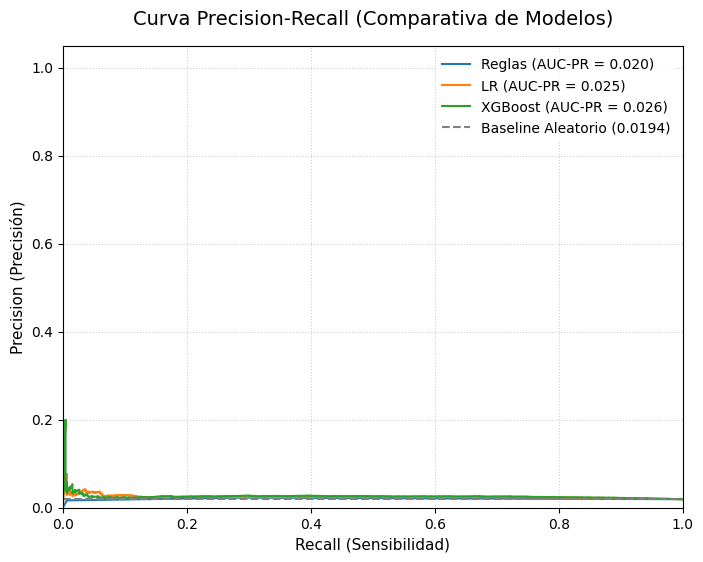

In [74]:
# 3. Generación y guardado del gráfico de Curvas Precision-Recall (PR)
fig_aucpr, ax = plt.subplots(figsize=(8, 6))

for nombre, data in modelos_config.items():
    precision, recall, _ = precision_recall_curve(y_test, data["probs"])
    auc_pr = average_precision_score(y_test, data["probs"])

    ax.plot(
        recall,
        precision,
        label=f"{nombre} (AUC-PR = {auc_pr:.3f})"
    )

# Configuración del estilo de la gráfica
ax.set_title("Curva Precision-Recall (Comparativa de Modelos)", fontsize=14, pad=15)
ax.set_xlabel("Recall (Sensibilidad)", fontsize=11)
ax.set_ylabel("Precision (Precisión)", fontsize=11)
ax.axhline(
    y=y_test.mean(),
    color='gray',
    linestyle='--',
    label=f"Baseline Aleatorio ({y_test.mean():.4f})"
)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Guardar la figura en el directorio configurado
try:
    fig_aucpr.savefig(FIGURES_DIR / "aucpr_models.png", dpi=150, bbox_inches="tight")
    print(f"Éxito: Gráfico guardado en '{FIGURES_DIR}/aucpr_models.png'")
except NameError:
    # Fallback por si FIGURES_DIR no está en el namespace local de Colab
    fig_aucpr.savefig("aucpr_models.png", dpi=150, bbox_inches="tight")
    print("Éxito: Gráfico guardado en directorio raíz (como 'aucpr_models.png')")

plt.show()

## §7 — Explicabilidad SHAP

**Owner:** Dev-2  
**Input:** `model_xgb`, `X_train`, `X_test`, `FEATURE_COLS`  
**Output:** `explainer`, `shap_values`, `fig_shap_bar`, `fig_shap_scatter`  
**Dependencias:** §5 (handoff H3)

In [75]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [76]:
# 1. Inicialización del explicador y cálculo de valores SHAP
# Usamos TreeExplainer que está optimizado para modelos basados en árboles como XGBoost
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test)  # La API moderna de SHAP devuelve un objeto Explanation explicativo completo

Éxito: Gráfico de barras SHAP guardado en '/content/drive/MyDrive/TFM-local/output/figures/shap_global_bar.png'


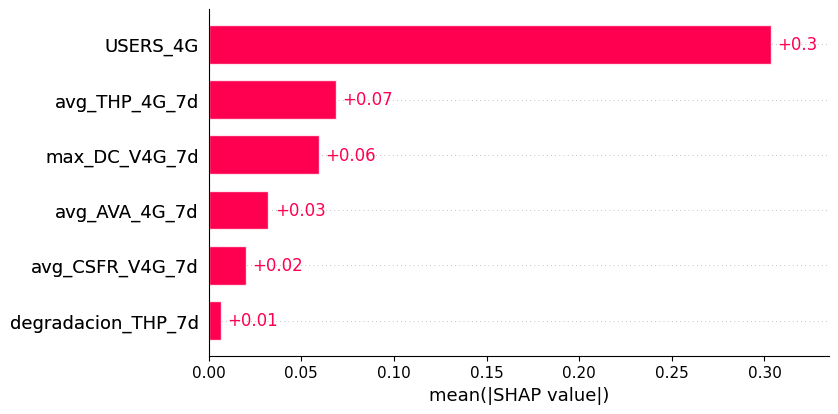

In [77]:
# 2. Generación y guardado del gráfico de barras (Importancia Global)
plt.figure(figsize=(10, 6))
# Usamos el objeto shap_values directo. Al pasarle .bar(), calcula la media de los valores absolutos de SHAP.
shap.plots.bar(shap_values, show=False)
fig_shap_bar = plt.gcf()

try:
    fig_shap_bar.savefig(FIGURES_DIR / "shap_global_bar.png", dpi=150, bbox_inches="tight")
    print(f"Éxito: Gráfico de barras SHAP guardado en '{FIGURES_DIR}/shap_global_bar.png'")
except NameError:
    fig_shap_bar.savefig("shap_global_bar.png", dpi=150, bbox_inches="tight")
    print("Éxito: Gráfico de barras SHAP guardado en el directorio raíz.")
plt.show()  # Se despliega en el notebook; el guardado en Drive ya quedó hecho arriba (referencia/documentación)

Éxito: Gráfico Beeswarm SHAP guardado en '/content/drive/MyDrive/TFM-local/output/figures/shap_beeswarm.png'


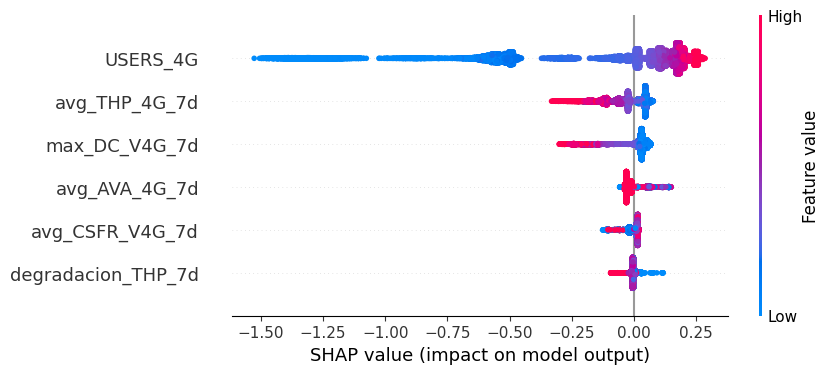

In [78]:
# 3. Generación y guardado del gráfico Beeswarm (Dirección del efecto)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
fig_shap_scatter = plt.gcf()

try:
    fig_shap_scatter.savefig(FIGURES_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
    print(f"Éxito: Gráfico Beeswarm SHAP guardado en '{FIGURES_DIR}/shap_beeswarm.png'")
except NameError:
    fig_shap_scatter.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
    print("Éxito: Gráfico Beeswarm SHAP guardado en el directorio raíz.")
plt.show()  # Se despliega en el notebook; el guardado en Drive ya quedó hecho arriba (referencia/documentación)

In [79]:
# 4. Implementación de la función de Negocio: Clasificación de Acción Recomendada

# Umbral relativo a la magnitud típica de SHAP de este modelo, no un valor fijo --
# un umbral fijo (ej. 0.01) no se adapta a la escala real de las features y en la
# práctica casi nunca dispara "sin señal clara" (ver mvp_diagnostico_red-local.ipynb).
_SHAP_ABS_VALUES = np.abs(shap_values.values if hasattr(shap_values, "values") else shap_values)
SHAP_SIGNAL_THRESHOLD = 0.1 * _SHAP_ABS_VALUES.mean()


def clasifica_accion(shap_row: dict) -> str:
    """
    Retorna la acción recomendada basada en el driver SHAP dominante del sitio.

    Recibe un diccionario con las contribuciones SHAP de las variables para un registro específico.
    """
    # Identificar la variable con el impacto predictivo positivo más alto (que empuja hacia el Reclamo)
    driver_dominante = max(shap_row, key=shap_row.get)
    valor_maximo_shap = shap_row[driver_dominante]

    # Si el impacto predictivo de la variable dominante es insignificante, no hay señal clara
    if valor_maximo_shap <= SHAP_SIGNAL_THRESHOLD:
        return "Monitoreo"

    # Clasificación de acción según la naturaleza del driver dominante
    # throughput/capacidad crónico o volumen de usuarios alto
    if any(kpis in driver_dominante.lower() for kpis in ["thp", "users", "traffic", "capacidad"]):
        return "Inversión tecnológica"

    # problemas de disponibilidad, caídas de llamadas o fallos de conexión recurrentes (AVA / DC / CSFR)
    elif any(kpis in driver_dominante.lower() for kpis in ["ava", "dc", "csfr", "drop", "disponibilidad"]):
        return "Mantenimiento programado"

    else:
        return "Monitoreo"


# Ejemplo: se corre sobre el primer sitio del test set, para dejar constancia
# de que la función funciona antes de que §9 la use fila por fila.
_shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values
_ejemplo = dict(zip(FEATURE_COLS, _shap_array[0]))
print(f"Ejemplo -- driver por sitio: {_ejemplo}")
print(f"Acción recomendada: {clasifica_accion(_ejemplo)}")

print("§7 completado con éxito — Dev-2")

Ejemplo -- driver por sitio: {'avg_AVA_4G_7d': np.float32(-0.031461746), 'max_DC_V4G_7d': np.float32(0.01634848), 'avg_THP_4G_7d': np.float32(0.043427844), 'degradacion_THP_7d': np.float32(-0.0024438305), 'avg_CSFR_V4G_7d': np.float32(-0.02442081), 'USERS_4G': np.float32(0.24705943)}
Acción recomendada: Inversión tecnológica
§7 completado con éxito — Dev-2


> **Hallazgo:** El driver SHAP dominante a nivel global es `USERS_4G` (tráfico/tamaño del sitio), muy por encima de cualquier KPI de calidad de red (AVA, DC, THP, CSFR) — consistente con las correlaciones débiles encontradas en §3.  
> **Implicación:** el modelo está capturando en buena parte un efecto de **exposición** (sitios con más usuarios generan mecánicamente más quejas) más que una señal pura de degradación de red. Esto limita la interpretabilidad accionable pedida por el cliente (qué KPI prioriza cada decisión) — para Entrega 3 hay que dejar esto explícito como limitación y no presentar `USERS_4G` como si fuera un "problema a resolver" en el ranking final.

## §8 — Segmentación de sitios

**Owner:** Dev-3  
**Input:** `df_weekly` (features agregadas por sitio)  
**Output:** `df_sites_clustered` (con columnas `cluster` y `perfil`)  
**Dependencias:** §2 (Parquet)

In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# TODO Dev-3:
# 1. Agregar df_weekly a nivel site_id (promedio del período)
# 2. StandardScaler sobre FEATURE_COLS
# 3. KMeans k=3..5, elegir k con silhouette score
# 4. Etiquetar clusters con perfil descriptivo
# 5. fig_cluster_scatter (PCA 2D o radar)

# df_sites_clustered esperado:
# site_id | avg_AVA | avg_DC | avg_THP | cluster | perfil

# fig_cluster_scatter.savefig(FIGURES_DIR / "cluster_sitios.png", dpi=150, bbox_inches="tight")

print("§8 pendiente — Dev-3")

§8 pendiente — Dev-3


In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Agregación a nivel site_id -- usando df_model (ya limpio de §4: sin inf, sin NaN de rolling)
df_sites_agg = df_model.groupby(SITE_ID_COL)[FEATURE_COLS].mean().reset_index()

# 2. Escalado
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_sites_agg[FEATURE_COLS])

# 3. Selección de k por silhouette score
resultados_k = {}
for k in range(3, 6):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    resultados_k[k] = silhouette_score(X_cluster, labels)
    print(f"k={k}: silhouette={resultados_k[k]:.4f}")

best_k = max(resultados_k, key=resultados_k.get)
print(f"\nMejor k: {best_k} (silhouette={resultados_k[best_k]:.4f})")

# 4. Clustering final
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_sites_agg["cluster"] = kmeans_final.fit_predict(X_cluster)

# 5. Etiquetado de perfil -- basado en centroides reales vs. umbrales de negocio
centroides = df_sites_agg.groupby("cluster")[FEATURE_COLS].mean()
print("\nCentroides por cluster:")
print(centroides)

k=3: silhouette=0.2958
k=4: silhouette=0.3018
k=5: silhouette=0.3109

Mejor k: 5 (silhouette=0.3109)

Centroides por cluster:
         avg_AVA_4G_7d  max_DC_V4G_7d  avg_THP_4G_7d  degradacion_THP_7d  \
cluster                                                                    
0             0.998223       0.002543      31.118148            1.016460   
1             0.991510       0.089870      25.088778            1.019047   
2             0.999511       0.001151      38.507813            1.035389   
3             0.998969       0.001909      14.998556            1.002857   
4             0.743246       0.002432      24.113247            1.065049   

         avg_CSFR_V4G_7d   USERS_4G  
cluster                              
0               0.000913  33.860361  
1               0.011332  24.463340  
2               0.294232  11.419927  
3               0.000900  72.559094  
4               0.000644  19.340900  


In [82]:
def etiqueta_perfil(row):
    if row["avg_AVA_4G_7d"] < 0.90:  # muy por debajo del umbral 0.98 -- no un simple roce
        return "Crítico - disponibilidad severa"
    elif row["max_DC_V4G_7d"] > DC_THRESHOLD * 2:  # más del doble del umbral de negocio
        return "Crítico - caídas de llamada"
    elif row["avg_CSFR_V4G_7d"] > 0.05:  # outlier claro vs. el resto de clusters (~0.001-0.01)
        return "Crítico - fallas de conexión (CSFR)"
    elif row["avg_THP_4G_7d"] < THP_THRESHOLD_MBP * 1.05:  # en o por debajo del umbral
        return "Congestión de capacidad"
    else:
        return "Estable"

df_sites_agg["perfil"] = df_sites_agg.apply(etiqueta_perfil, axis=1)
print(df_sites_agg["perfil"].value_counts())
print()
print(df_sites_agg.groupby("perfil")[FEATURE_COLS].mean())  # verificación cruzada

perfil
Estable                                1649
Congestión de capacidad                 660
Crítico - caídas de llamada              17
Crítico - fallas de conexión (CSFR)       7
Crítico - disponibilidad severa           4
Name: count, dtype: int64

                                     avg_AVA_4G_7d  max_DC_V4G_7d  \
perfil                                                              
Congestión de capacidad                   0.998899       0.002410   
Crítico - caídas de llamada               0.992340       0.084454   
Crítico - disponibilidad severa           0.743246       0.002432   
Crítico - fallas de conexión (CSFR)       0.999509       0.001576   
Estable                                   0.998470       0.002105   

                                     avg_THP_4G_7d  degradacion_THP_7d  \
perfil                                                                   
Congestión de capacidad                  11.244715            1.003004   
Crítico - caídas de llamada             

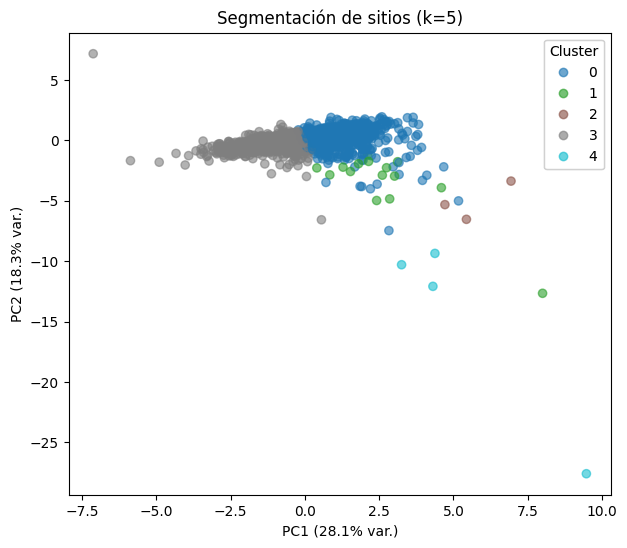

§8 completado — 2337 sitios en 5 clusters


In [83]:
# 6. Figura PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig_cluster_scatter, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_sites_agg["cluster"], cmap="tab10", alpha=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title(f"Segmentación de sitios (k={best_k})")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
fig_cluster_scatter.savefig(FIGURES_DIR / "cluster_sitios.png", dpi=150, bbox_inches="tight")
plt.show()

df_sites_clustered = df_sites_agg[[SITE_ID_COL, "avg_AVA_4G_7d", "max_DC_V4G_7d", "avg_THP_4G_7d", "cluster", "perfil"]].rename(
    columns={"avg_AVA_4G_7d": "avg_AVA", "max_DC_V4G_7d": "avg_DC", "avg_THP_4G_7d": "avg_THP"}
)
print(f"§8 completado — {len(df_sites_clustered)} sitios en {best_k} clusters")

**Hallazgo:** La segmentación con k=5 (silhouette=0.31) separa los sitios en un grupo mayoritario sin problemas (perfil "Estable", 1,649 sitios, 70.6%), un segundo grupo grande con THP cerca del umbral de negocio ("Congestión de capacidad", 660 sitios, 28.2%), y tres grupos pequeños pero claramente diferenciados en el espacio de features: "Crítico - caídas de llamada" (17 sitios, DC 4.5x el umbral), "Crítico - fallas de conexión CSFR" (7 sitios, CSFR ~250x el resto de clusters) y "Crítico - disponibilidad severa" (4 sitios, AVA muy por debajo del umbral 0.98). Estos tres últimos grupos aparecen también como puntos claramente aislados en la proyección PCA (46.4% de varianza explicada en 2D), lo que corrobora que la separación no es artefacto del algoritmo sino que refleja sitios con comportamiento genuinamente atípico.
Implicación: el hallazgo más accionable es el grupo CSFR; el clustering revela un patrón de falla (tasa de fallo en establecimiento de llamada muy elevada) que no está cubierto por ningún umbral de negocio definido en §0 (solo se definieron umbrales para AVA, DC y THP). Esto sugiere una recomendación concreta para el cliente: incorporar un umbral explícito de CSFR en las reglas de monitoreo futuras, ya que actualmente esos 7 sitios solo se identifican vía clustering y no vía las reglas de negocio originales. Por otro lado, el silhouette score moderado (0.31) indica que, fuera de los grupos críticos claramente aislados, la frontera entre "Estable" y "Congestión de capacidad" es menos nítida — es una limitación esperable dado que ambos grupos comparten valores similares de AVA y DC, diferenciándose principalmente en THP y USERS_4G.

## §9 — Ranking accionable (output final)

**Owner:** Dev-3  
**Input:** `df_weekly` (test), `y_prob_xgb`, `shap_values`, `df_sites_clustered`  
**Output:** `df_ranking` → `output/ranking_sitios.parquet`  
**Dependencias:** §5, §7, §8

In [84]:
# TODO Dev-3: construir df_ranking con schema:
# site_id | score_riesgo | prioridad_sitio | kpis_driver |
# umbral_incumplido | accion_recomendada | cluster | semanas_en_riesgo

# df_ranking = df_test[[SITE_ID_COL]].copy()
# df_ranking["score_riesgo"] = y_prob_xgb
# df_ranking["prioridad_sitio"] = 0  # actualizar cuando cliente provea campo
# df_ranking["kpis_driver"] = ...    # top 2 features SHAP por sitio
# df_ranking["umbral_incumplido"] = ...
# df_ranking["accion_recomendada"] = df_ranking.apply(lambda r: clasifica_accion(...), axis=1)
# df_ranking = df_ranking.merge(df_sites_clustered[[SITE_ID_COL, "cluster"]], on=SITE_ID_COL, how="left")
# df_ranking["semanas_en_riesgo"] = ...
# df_ranking = df_ranking.sort_values("score_riesgo", ascending=False)
# df_ranking.to_parquet(RANKING_PATH, index=False)

# print(f"Ranking guardado: {RANKING_PATH}")
# print(f"Top 10 sitios de mayor riesgo:")
# display(df_ranking.head(10))

print("§9 pendiente — Dev-3")

§9 pendiente — Dev-3


In [85]:
# 1. Base: site_id + score de riesgo (alineados posicionalmente con X_test)
df_ranking = df_test[[SITE_ID_COL]].reset_index(drop=True).copy()
df_ranking["score_riesgo"] = y_prob_xgb

# 2. Prioridad por terciles (provisional, hasta que el cliente defina el campo real)
df_ranking["prioridad_sitio"] = pd.qcut(
    df_ranking["score_riesgo"], q=3, labels=["Baja", "Media", "Alta"]
)

# 3. kpis_driver: top-2 features por |SHAP| en cada fila
# Nota: se incluye USERS_4G sin filtrar -- ver limitación documentada en §7/§9 sobre
# efecto de exposición vs. degradación real de red.
shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values
top2_idx = np.argsort(-np.abs(shap_array), axis=1)[:, :2]
df_ranking["kpis_driver"] = [
    ", ".join([FEATURE_COLS[i] for i in fila]) for fila in top2_idx
]

# 4. umbral_incumplido: reglas de negocio violadas (reutiliza lógica de RulesBaseline)
def umbrales_violados(row):
    violados = []
    if row["avg_AVA_4G_7d"] < AVA_THRESHOLD:
        violados.append("AVA")
    if row["max_DC_V4G_7d"] > DC_THRESHOLD:
        violados.append("DC")
    if row["avg_THP_4G_7d"] < THP_THRESHOLD_MBP:
        violados.append("THP")
    return ", ".join(violados) if violados else "ninguno"

df_ranking["umbral_incumplido"] = X_test.reset_index(drop=True).apply(umbrales_violados, axis=1)

# 5. accion_recomendada: aplica clasifica_accion() fila por fila con el SHAP real, sin filtrar
df_ranking["accion_recomendada"] = [
    clasifica_accion(dict(zip(FEATURE_COLS, fila))) for fila in shap_array
]

# 6. Merge con clusters y perfil de §8
df_ranking = df_ranking.merge(
    df_sites_clustered[[SITE_ID_COL, "cluster", "perfil"]], on=SITE_ID_COL, how="left"
)

# 7. semanas_en_riesgo: histórico completo por sitio (todo df_weekly, no solo test)
semanas_riesgo = df_weekly.groupby(SITE_ID_COL)[TARGET_COL].sum().rename("semanas_en_riesgo")
df_ranking = df_ranking.merge(semanas_riesgo, on=SITE_ID_COL, how="left")

# 8. Deduplicar a nivel sitio: para cada site_id, quedarse con la fila de mayor score_riesgo
df_ranking = (
    df_ranking
    .sort_values("score_riesgo", ascending=False)
    .drop_duplicates(subset=SITE_ID_COL, keep="first")
    .reset_index(drop=True)
)

print(f"Total sitios únicos en ranking: {len(df_ranking)}")
print(f"¿Quedan duplicados? {df_ranking[SITE_ID_COL].duplicated().sum()}")

# 9. Orden final y guardado
df_ranking = df_ranking.sort_values("score_riesgo", ascending=False).reset_index(drop=True)
df_ranking.to_parquet(RANKING_PATH, index=False)

print(f"Ranking guardado: {RANKING_PATH}")
print(f"Total sitios en ranking: {len(df_ranking)}")
print("\nTop 10 sitios de mayor riesgo:")
display(df_ranking.head(10))

Total sitios únicos en ranking: 2335
¿Quedan duplicados? 0
Ranking guardado: /content/drive/MyDrive/TFM-local/output/ranking_sitios.parquet
Total sitios en ranking: 2335

Top 10 sitios de mayor riesgo:


,site_id,score_riesgo,prioridad_sitio,kpis_driver,umbral_incumplido,accion_recomendada,cluster,perfil,semanas_en_riesgo
0,92,0.632267,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,1
1,2583,0.628532,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,3
2,1240,0.624757,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,0
3,576,0.624158,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,2
4,1043,0.623970,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,0
5,158,0.623373,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,1
6,1544,0.623316,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,1
7,1557,0.622877,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,1
8,742,0.622721,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,4
9,111,0.622721,Alta,"USERS_4G, avg_AVA_4G_7d",THP,Inversión tecnológica,3,Congestión de capacidad,0


In [86]:
# ¿Cuántos sitios distintos tiene realmente el patrón dominante del top 10?
print(df_ranking.head(30)[["kpis_driver", "umbral_incumplido", "cluster"]].value_counts())

# ¿Qué tan concentrado está el score de riesgo? Si el modelo distingue poco,
# los scores del top-N deberían estar muy cerca entre sí.
print(df_ranking["score_riesgo"].describe())
print(df_ranking.head(30)["score_riesgo"].std())

kpis_driver              umbral_incumplido  cluster
USERS_4G, avg_AVA_4G_7d  THP                3          27
                         ninguno            3           2
                                            0           1
Name: count, dtype: int64
count    2335.000000
mean        0.497419
std         0.095710
min         0.137694
25%         0.470173
50%         0.530191
75%         0.562072
max         0.632267
Name: score_riesgo, dtype: float64
0.0052862917073071


Hallazgo: dentro del top de sitios de mayor riesgo, el score de riesgo y los drivers SHAP muestran muy poca variación (std=0.005 en el top 30, frente a 0.096 en el ranking completo); 27 de los 30 sitios comparten el mismo patrón de driver dominante y umbral incumplido.
Implicación: el modelo final (max_depth=2, elegido por bajo overfitting en CV interno con clases muy desbalanceadas) prioriza correctamente el riesgo agregado, pero no diferencia finamente entre los sitios de mayor urgencia. Para uso operativo, el prioridad_sitio (Alta/Media/Baja) es más confiable como criterio de triage que el orden exacto dentro del grupo "Alta". Aumentar la profundidad del árbol podría mejorar esta granularidad, a costa de mayor riesgo de overfitting dado el desbalance de clases (~2.5% positivos) — queda como trabajo futuro fuera del alcance de este MVP.

---

## Checklist de entrega

- [x] Kernel Restart → Run All completa sin error
- [x] `output/modeling_dataset_weekly.parquet` generado
- [x] `output/semanal/ranking_sitios.parquet` generado con 9 columnas (8 del schema + `perfil`)
- [x] `df_metrics` impreso con AUC-PR para los 3 modelos
- [x] Al menos 1 figura SHAP global en `output/figures/`
- [x] `RANDOM_STATE = 42` en todos los modelos
- [x] `TEST_CUTOFF_DATE` documentado con justificación (17 train / 10 test semanas)
- [x] Variables con nombres definidos en `entregables/pipeline.md`